In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from util import *
import os, json
from D3PM_function import *
from tauLDR_function import *
from SEDD_function import *
from discreteFM_function import *
from poisson_jump_function import *
import pandas as pd
import ot

# import importlib, SEDD_function
# importlib.reload(SEDD_function)
# from SEDD_function import *


from count_FM_function_v3 import *
from DirichletFM_function import *
from models import * 
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# Comparison Models:

1. D3PM (NeurIPS 2021)
2. tauLDR (tau-leaping denoising reversal)/ CTMC (NeurIPS 2022)
3. SEDD (ICML 2024)
4. disrete FM (NeurIPS 2024)
5. Dirichlet FM (ICML 2024)
6. Poisson jump (ICML 2023)
7. ours (count-FM)

# 1. Generate Data

In [2]:
np.random.seed(0)
N = 1000

# target
k_target    = np.array([[60.0, 5.0],  [60.0, 40.0]])
rate_target = np.array([[1.0, 1.0],  [1.0, 1.0]])
z = (np.random.rand(N) < 0.5).astype(int)
lam1 = np.random.gamma(shape=k_target[z], scale=1.0 / rate_target[z])
X1 = np.random.poisson(lam1)

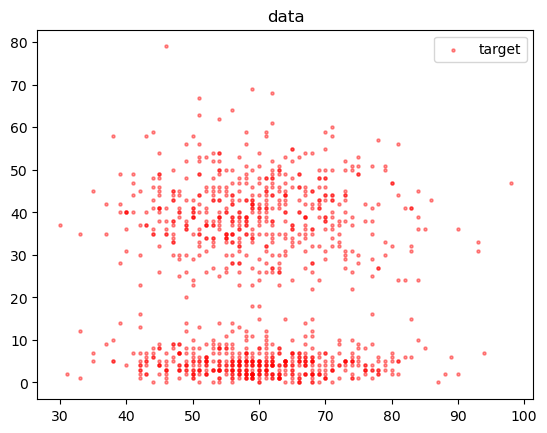

In [3]:
alpha_pt = 0.4
plt.scatter(X1[:,0], X1[:,1], c = 'r', s = 5, alpha = alpha_pt, label = 'target');
plt.title('data');
plt.legend();

# 2. Preperation

## 2.1 count FM

In [4]:
eps_t = 1e-4 # add some eps to avoid rate blow up for t = 1
eps_log = 1e-8 # for Poisson deviance...
lr = 1e-3
X1_torch = torch.tensor(X1)
N, d = X1_torch.shape

In [5]:
separate_heads_countFM = False
if not separate_heads_countFM:
    net_base = MLP(dim=d, out_dim=2*d, w=32, time_varying=True).to(device)
    net = MLP_rate(net_base)
    params_countFM = list(net.parameters())
    nets_countFM = net
else:
    net_base_b = MLP(dim=d, out_dim=d, w=32, time_varying=True).to(device)
    net_base_d = MLP(dim=d, out_dim=d, w=32, time_varying=True).to(device)
    net_b = MLP_rate(net_base_b)
    net_d = MLP_rate(net_base_d)
    params_countFM = list(net_b.parameters()) + list(net_d.parameters())
    nets_countFM = [net_b, net_d]

In [6]:
opt_countFM = torch.optim.Adam(params_countFM, lr=lr)

### OT version

In [7]:
separate_heads_countFM_OT = False
if not separate_heads_countFM_OT:
    net_base = MLP(dim=d, out_dim=2*d, w=32, time_varying=True).to(device)
    net = MLP_rate(net_base)
    params_countFM_OT = list(net.parameters())
    nets_countFM_OT = net
else:
    net_base_b = MLP(dim=d, out_dim=d, w=32, time_varying=True).to(device)
    net_base_d = MLP(dim=d, out_dim=d, w=32, time_varying=True).to(device)
    net_b = MLP_rate(net_base_b)
    net_d = MLP_rate(net_base_d)
    params_countFM_OT = list(net_b.parameters()) + list(net_d.parameters())
    nets_countFM_OT = [net_b, net_d]

In [8]:
opt_countFM_OT = torch.optim.Adam(params_countFM_OT, lr=lr)

## 2.2 Dirichlet FM

In [9]:
train_counts, C_max = build_count_dataset(X1, C_max=None, margin=2)
train_counts = train_counts.to(device)

# alpha_min, alpha_max, alpha_scale = suggest_alpha_hyper(C_max)
alpha_min, alpha_max, alpha_scale = 1.0, 100.0, 20.0 # defaul values in their code
print(alpha_min, alpha_max, alpha_scale)

1.0 100.0 20.0


In [10]:
condflow_counts = DirichletConditionalFlow(
    K=C_max + 1,
    alpha_min=alpha_min,
    alpha_max=alpha_max,
    alpha_spacing=0.01,   # same as repo
)

In [11]:
N, D = train_counts.shape
K = C_max + 1
classifier_DirFM = DirichletFMClassifier(num_dims=D, K=K, mlp_width=32, time_varying=True).to(device)
opt_DirFM = torch.optim.Adam(classifier_DirFM.parameters(), lr=lr)

## 2.3 D3PM

In [12]:
K = C_max + 1
classifier_D3PM = D3PMClassifier(num_dims=D, K=K, mlp_width=32, time_varying=True).to(device)
opt_D3PM = torch.optim.Adam(classifier_D3PM.parameters(), lr=lr)

## 2.4 tauLDR

In [13]:
classifier_tauLDR = TauLDRClassifier(dim=D, K=K, w=32, C_max=C_max).to(device)
opt_tauLDR = torch.optim.Adam(classifier_tauLDR.parameters(), lr=lr)

## 2.5 SEDD

In [14]:
K = C_max + 1
classifier_SEDD = SEDDUniformClassifier(dim=D, K=K, C_max=C_max, hidden=32, depth=3).to(device)
opt_SEDD = torch.optim.Adam(classifier_SEDD.parameters(), lr=lr)

## 2.6 discrete FM

In [15]:
N, D = train_counts.shape
K = C_max + 1

classifier_DisFM = DiscreteFMClassifier(num_dims=D, K=K, C_max=C_max, mlp_width=32).to(device)
opt_DisFM = torch.optim.Adam(classifier_DisFM.parameters(), lr=lr)

## 2.7 Poisson jump

In [16]:
decoder_PJUMP = PoissonJumpDecoder(dim=D, C_max=C_max, hidden=256, n_layers=2).to(device)
opt_PJUMP = torch.optim.Adam(decoder_PJUMP.parameters(), lr=lr)

# 3. Train

In [17]:
batch_size = 1024
num_epochs = 20000

In [63]:
CKPT_DIR = "./toy_model_ckpts"
FIG_DIR = "figures_paper"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

loaded_countFM = False
loaded_countFM_OT = False
loaded_DirFM   = False
loaded_D3PM    = False
loaded_tauLDR  = False
loaded_SEDD    = False
loaded_DisFM   = False
loaded_PJUMP   = False

nets_countFM = globals().get("nets_countFM", None)
nets_countFM_OT = globals().get("nets_countFM_OT", None)
opt_countFM = globals().get("opt_countFM", None)
opt_countFM_OT = globals().get("opt_countFM_OT", None)
separate_heads_countFM = globals().get("separate_heads_countFM", False)
separate_heads_countFM_OT = globals().get("separate_heads_countFM_OT", False)

def _load_countfm_bundle(path, lr_common, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    nets = ckpt["model"]

    if isinstance(nets, list):
        separate_heads_local = True
        nets = [m.to(device) for m in nets]
        params = list(nets[0].parameters()) + list(nets[1].parameters())
        nets[0].eval()
        nets[1].eval()
    else:
        separate_heads_local = False
        nets = nets.to(device)
        params = list(nets.parameters())
        nets.eval()

    opt = torch.optim.Adam(params, lr=lr_common)
    opt.load_state_dict(ckpt["optimizer_state_dict"])
    return nets, opt, separate_heads_local, ckpt

meta_path = os.path.join(CKPT_DIR, "meta.json")
if os.path.exists(meta_path):
    with open(meta_path, "r") as f:
        meta = json.load(f)

    n_step = int(meta.get("n_step", 1000))
    lr_common = float(meta.get("lr_common", lr))
    lr_pjump = float(meta.get("lr_pjump", opt_PJUMP.param_groups[0]["lr"]))

    # count-FM (non-OT)
    p = os.path.join(CKPT_DIR, "countFM.pt")
    if os.path.exists(p):
        nets_countFM, opt_countFM, separate_heads_countFM, ckpt_countFM = _load_countfm_bundle(
            p, lr_common, device
        )
        loaded_countFM = True
        print("Loaded count-FM checkpoint.")

    # count-FM-OT
    p = os.path.join(CKPT_DIR, "countFM_OT.pt")
    if os.path.exists(p):
        nets_countFM_OT, opt_countFM_OT, separate_heads_countFM_OT, ckpt_countFM_OT = _load_countfm_bundle(
            p, lr_common, device
        )
        loaded_countFM_OT = True
        print("Loaded count-FM-OT checkpoint.")

    # keep old name for backward compatibility with later cells if needed
    if loaded_countFM:
        separate_heads = separate_heads_countFM
    elif loaded_countFM_OT:
        separate_heads = separate_heads_countFM_OT

    # Dirichlet-FM
    p = os.path.join(CKPT_DIR, "DirichletFM.pt")
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=device, weights_only=False)
        classifier_DirFM = ckpt["model"].to(device)
        opt_DirFM = torch.optim.Adam(classifier_DirFM.parameters(), lr=lr_common)
        opt_DirFM.load_state_dict(ckpt["optimizer_state_dict"])
        classifier_DirFM.eval()
        classifier_DirFM_OT = classifier_DirFM
        opt_DirFM_OT = opt_DirFM
        loaded_DirFM = True
        print("Loaded Dirichlet-FM checkpoint.")

    # D3PM
    p = os.path.join(CKPT_DIR, "D3PM.pt")
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=device, weights_only=False)
        classifier_D3PM = ckpt["model"].to(device)
        opt_D3PM = torch.optim.Adam(classifier_D3PM.parameters(), lr=lr_common)
        opt_D3PM.load_state_dict(ckpt["optimizer_state_dict"])
        classifier_D3PM.eval()
        classifier_D3PM_OT = classifier_D3PM
        opt_D3PM_OT = opt_D3PM
        loaded_D3PM = True
        print("Loaded D3PM checkpoint.")

    # tauLDR
    p = os.path.join(CKPT_DIR, "tauLDR.pt")
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=device, weights_only=False)
        classifier_tauLDR = ckpt["model"].to(device)
        opt_tauLDR = torch.optim.Adam(classifier_tauLDR.parameters(), lr=lr_common)
        opt_tauLDR.load_state_dict(ckpt["optimizer_state_dict"])
        classifier_tauLDR.eval()
        classifier_tauLDR_OT = classifier_tauLDR
        opt_tauLDR_OT = opt_tauLDR
        loaded_tauLDR = True
        print("Loaded tauLDR checkpoint.")

    # SEDD
    p = os.path.join(CKPT_DIR, "SEDD.pt")
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=device, weights_only=False)
        classifier_SEDD = ckpt["model"].to(device)
        opt_SEDD = torch.optim.Adam(classifier_SEDD.parameters(), lr=lr_common)
        opt_SEDD.load_state_dict(ckpt["optimizer_state_dict"])
        classifier_SEDD.eval()
        classifier_SEDD_OT = classifier_SEDD
        opt_SEDD_OT = opt_SEDD
        loaded_SEDD = True
        print("Loaded SEDD checkpoint.")

    # discrete-FM
    p = os.path.join(CKPT_DIR, "discreteFM.pt")
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=device, weights_only=False)
        classifier_DisFM = ckpt["model"].to(device)
        opt_DisFM = torch.optim.Adam(classifier_DisFM.parameters(), lr=lr_common)
        opt_DisFM.load_state_dict(ckpt["optimizer_state_dict"])
        classifier_DisFM.eval()
        classifier_DisFM_OT = classifier_DisFM
        opt_DisFM_OT = opt_DisFM
        loaded_DisFM = True
        print("Loaded discrete-FM checkpoint.")

    # Poisson-JUMP
    p = os.path.join(CKPT_DIR, "PoissonJUMP.pt")
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=device, weights_only=False)
        decoder_PJUMP = ckpt["model"].to(device)
        opt_PJUMP = torch.optim.Adam(decoder_PJUMP.parameters(), lr=lr_pjump)
        opt_PJUMP.load_state_dict(ckpt["optimizer_state_dict"])
        decoder_PJUMP.eval()
        decoder_PJUMP_OT = decoder_PJUMP
        opt_PJUMP_OT = opt_PJUMP
        loaded_PJUMP = True
        print("Loaded Poisson-JUMP checkpoint.")
else:
    print("No meta.json found, train all models from scratch.")

Loaded count-FM checkpoint.
Loaded count-FM-OT checkpoint.
Loaded Dirichlet-FM checkpoint.
Loaded D3PM checkpoint.
Loaded tauLDR checkpoint.
Loaded SEDD checkpoint.
Loaded discrete-FM checkpoint.
Loaded Poisson-JUMP checkpoint.


## 3.1 Count FM

In [19]:
loss_mode = 'poisson' # or 'poisson'/ 'l2'

In [20]:
if loaded_countFM:
    print("Skip count-FM training.")
    loss_countFM = None
else:
    nets_countFM, loss_countFM = CountFM_train(
        X1_torch, nets_countFM, opt_countFM, num_epochs,
        batch_size, device, separate_heads=separate_heads_countFM,
        x0_mode="uniform",
        ot_cost="none",
        C_max=C_max,
        eps_t=eps_t, eps_log=eps_log, loss_mode=loss_mode,
    )

Skip count-FM training.


### OT version

In [64]:
if loaded_countFM_OT:
    print("Skip count-FM-OT training.")
    loss_countFM_OT = None
else:
    nets_countFM_OT, loss_countFM_OT = CountFM_train(
        X1_torch, nets_countFM_OT, opt_countFM_OT, num_epochs,
        batch_size, device, separate_heads=separate_heads_countFM_OT,
        x0_mode="uniform",
        ot_cost="sym_poisson",
        C_max=C_max,
        eps_t=eps_t, eps_log=eps_log, loss_mode=loss_mode,
    )

Skip count-FM-OT training.


In [65]:
opt_countFM_OT = torch.optim.Adam(params_countFM_OT, lr=5e-4)

nets_countFM_OT, loss_countFM_OT = CountFM_train(
    X1_torch, nets_countFM_OT, opt_countFM_OT, 5000,
    batch_size, device, separate_heads=separate_heads_countFM_OT,
    x0_mode="uniform",
    ot_cost="sym_poisson",
    C_max=C_max,
    eps_t=eps_t, eps_log=eps_log, loss_mode=loss_mode,
)

  0%|                                                  | 0/5000 [00:00<?, ?it/s]/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  0%|                                          | 2/5000 [00:00<06:37, 12.59it/s]

[CountFM][epoch 0] loss=-107.318085


 20%|███████▊                               | 1002/5000 [01:19<05:10, 12.86it/s]

[CountFM][epoch 1000] loss=-100.404694


 40%|███████████████▌                       | 2002/5000 [02:38<03:52, 12.88it/s]

...

 60%|███████████████████████▍               | 3002/5000 [03:58<02:37, 12.69it/s]

[CountFM][epoch 3000] loss=-104.810905


 80%|███████████████████████████████▏       | 4002/5000 [05:17<01:18, 12.70it/s]

[CountFM][epoch 4000] loss=-101.305023


100%|███████████████████████████████████████| 5000/5000 [06:37<00:00, 12.59it/s]


## 3.2 Dirichlet FM

In [22]:
t_schedule = 'exp'

In [23]:
if loaded_DirFM:
    print("Skip Dirichlet-FM training.")
    loss_DirFM = None
else:
    classifier_DirFM, loss_DirFM = DFM_train(
        train_counts, C_max, batch_size, num_epochs,
        classifier_DirFM, alpha_scale, alpha_min, alpha_max, t_schedule,
        opt_DirFM, device
    )

Skip Dirichlet-FM training.


## 3.3 D3PM

In [24]:
if loaded_D3PM:
    print("Skip D3PM training.")
    loss_D3PM = None
else:
    n_step = 1000
    classifier_D3PM, loss_D3PM = D3PM_train(
        train_counts, C_max, batch_size, num_epochs,
        classifier_D3PM, opt_D3PM, device,
        num_steps=n_step,
        schedule="cosine",
        lambda_aux=1e-3,
    )

Skip D3PM training.


## 3.4 tauLDR

In [25]:
if loaded_tauLDR:
    print("Skip tauLDR training.")
    loss_tauLDR = None
else:
    classifier_tauLDR, loss_tauLDR = tauldr_train(
        train_counts=train_counts,
        C_max=C_max,
        batch_size=batch_size,
        num_epochs=num_epochs,
        classifier=classifier_tauLDR,
        opt=opt_tauLDR,
        device=device,
        schedule="exp",
        t_min=1e-3,
    )

Skip tauLDR training.


## 3.5 SEDD

In [26]:
if loaded_SEDD:
    print("Skip SEDD training.")
    loss_SEDD = None
else:
    classifier_SEDD, loss_SEDD = sedd_train(
        train_counts=train_counts,
        C_max=C_max,
        batch_size=batch_size,
        num_epochs=num_epochs,
        classifier=classifier_SEDD,
        opt=opt_SEDD,
        device=device,
        schedule="loglinear",
        eps=1e-3,
        log_every=200,
    )

Skip SEDD training.


## 3.6 discrete FM

In [27]:
if loaded_DisFM:
    print("Skip discrete-FM training.")
    loss_DisFM = None
else:
    classifier_DisFM, loss_DisFM = discrete_fm_train(
        train_counts=train_counts,
        C_max=C_max,
        batch_size=batch_size,
        num_epochs=num_epochs,
        classifier=classifier_DisFM,
        opt=opt_DisFM,
        device=device,
        schedule="quadratic",
        t_min=1e-3,
        x0_mode="uniform",
    )

Skip discrete-FM training.


## 3.7 Poisson jump

In [28]:
if loaded_PJUMP:
    print("Skip Poisson-JUMP training.")
    loss_PJUMP = None
else:
    decoder_PJUMP, loss_PJUMP = pjump_train(
        train_counts=train_counts,
        C_max=C_max,
        batch_size=batch_size,
        num_epochs=num_epochs,
        decoder=decoder_PJUMP,
        opt=opt_PJUMP,
        device=device,
        n_step=n_step,
        schedule="exp",
        alpha_end=1e-3,
        lambda_scale=1.0,
    )

Skip Poisson-JUMP training.


# 4. Generation

In [66]:
import random

SEED_BASE = 20260320
MODEL_SEEDS = {
    "x0_new": SEED_BASE + 0,
    "countFM": SEED_BASE + 1,
    "countFM_OT": SEED_BASE + 2,
    "DirFM": SEED_BASE + 3,
    "D3PM": SEED_BASE + 4,
    "tauLDR": SEED_BASE + 5,
    "SEDD": SEED_BASE + 6,
    "DisFM": SEED_BASE + 7,
    "PJUMP": SEED_BASE + 8,
    "eval": SEED_BASE + 9,
}

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

set_all_seeds(MODEL_SEEDS["x0_new"])

N_new = 1000
dist0 = torch.distributions.Dirichlet(torch.ones(K, device=device))
x = dist0.rsample((N_new, D))     # [B,D,K]
x0_prob = x / x.sum(-1, keepdim=True)

x0_new = x0_prob.argmax(-1).cpu().long()
x0_new_torch = x0_new.clone()

## 4.1 Binomial bridge

In [67]:
set_all_seeds(MODEL_SEEDS["countFM"])
x1_countFM, traj_countFM = sample_euler(
    nets_countFM,
    n_step,
    x0_new_torch,
    device,
    eps_t,
    eps_log,
    separate_heads_countFM,
)
x1_countFM_np = x1_countFM.detach().cpu().numpy()
traj_countFM_np = traj_countFM.detach().cpu().numpy()

set_all_seeds(MODEL_SEEDS["countFM_OT"])
x1_countFM_OT, traj_countFM_OT = sample_euler(
    nets_countFM_OT,
    n_step,
    x0_new_torch,
    device,
    eps_t,
    eps_log,
    separate_heads_countFM_OT,
)
x1_countFM_OT_np = x1_countFM_OT.detach().cpu().numpy()
traj_countFM_OT_np = traj_countFM_OT.detach().cpu().numpy()

## 4.2 Dirichlet bridge

In [31]:
set_all_seeds(MODEL_SEEDS["DirFM"])
X1_DirFM, traj_DirFM = sample_dfm_counts(
    classifier=classifier_DirFM,
    condflow=condflow_counts,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    num_steps=n_step,
    alpha_min=alpha_min,
    alpha_max=alpha_max,
    device=device,
    return_traj=True,
    x0=x0_prob,
)
X1_DirFM_np = X1_DirFM.detach().cpu().numpy()
traj_DirFM_np = traj_DirFM.detach().cpu().numpy()

/home/ganchao/Desktop/count_FM/DirichletFM/utils/flow_utils.py:136: RuntimeWarning: divide by zero encountered in divide
  out = np.where((bs ** (alpha - 1)) > 0, out2 / (bs ** (alpha - 1)), 0)
/home/ganchao/Desktop/count_FM/DirichletFM/utils/flow_utils.py:136: RuntimeWarning: invalid value encountered in divide
  out = np.where((bs ** (alpha - 1)) > 0, out2 / (bs ** (alpha - 1)), 0)


## 4.3 D3PM

In [32]:
set_all_seeds(MODEL_SEEDS["D3PM"])
X1_D3PM, traj_D3PM = sample_d3pm_counts(
    classifier=classifier_D3PM,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    num_steps=n_step,
    device=device,
    xT=x0_new_torch.to(device).long(),
    return_traj=True,
)
X1_D3PM_np = X1_D3PM.detach().cpu().numpy()
traj_D3PM_np = traj_D3PM.detach().cpu().numpy()

## 4.4 tauLDR

In [33]:
set_all_seeds(MODEL_SEEDS["tauLDR"])
x1_tauLDR, traj_tauLDR = tauldr_sample(
    classifier=classifier_tauLDR,
    n_step=n_step,
    x_noise=x0_new_torch,
    C_max=C_max,
    device=device,
    schedule="exp",
    t_min=1e-3,
    return_traj=True,
)

x1_tauLDR_np = x1_tauLDR.detach().cpu().numpy()
traj_tauLDR_np = traj_tauLDR.detach().cpu().numpy()

In [34]:
x1_tauLDR_np = x1_tauLDR.detach().cpu().numpy()
traj_tauLDR_np = traj_tauLDR.detach().cpu().numpy()

In [35]:
x1_tauLDR_np.shape

(1000, 2)

## 4.5 SEDD

In [36]:
set_all_seeds(MODEL_SEEDS["SEDD"])
X1_SEDD, traj_SEDD = sample_sedd_uniform(
    classifier=classifier_SEDD,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    num_steps=n_step,
    device=device,
    schedule="loglinear",
    eps=1e-3,
    x_init=x0_new_torch.to(device).long(),
    return_traj=True,
)
X1_SEDD_np = X1_SEDD.detach().cpu().numpy()
traj_SEDD_np = traj_SEDD.detach().cpu().numpy()

## 4.6 discrete FM

In [37]:
set_all_seeds(MODEL_SEEDS["DisFM"])
X1_DisFM, traj_DisFM = sample_discrete_fm(
    classifier=classifier_DisFM,
    x0=x0_new_torch,
    C_max=C_max,
    num_steps=n_step,
    device=device,
    schedule="quadratic",
    t_min=1e-3,
    return_traj=True,
)
X1_DisFM_np = X1_DisFM.detach().cpu().numpy()
traj_DisFM_np = traj_DisFM.detach().cpu().numpy()

In [38]:
X1_DisFM_np = X1_DisFM.detach().cpu().numpy()
traj_DisFM_np = traj_DisFM.detach().cpu().numpy()

## 4.7 Poisson jump

In [39]:
set_all_seeds(MODEL_SEEDS["PJUMP"])
X1_PJUMP, traj_PJUMP = pjump_sample_counts(
    decoder=decoder_PJUMP,
    num_samples=N_new,
    D=D,
    C_max=C_max,
    n_step=n_step,
    device=device,
    schedule="exp",
    alpha_end=1e-3,
    lambda_scale=1.0,
    return_traj=True,
)

In [68]:
X1_PJUMP_np = X1_PJUMP.detach().cpu().numpy()
traj_PJUMP_np = traj_PJUMP.detach().cpu().numpy()

# OT-name copies for downstream code consistency
classifier_DirFM_OT = classifier_DirFM
classifier_D3PM_OT = classifier_D3PM
classifier_tauLDR_OT = classifier_tauLDR
classifier_SEDD_OT = classifier_SEDD
classifier_DisFM_OT = classifier_DisFM
decoder_PJUMP_OT = decoder_PJUMP

X1_DirFM_OT = X1_DirFM.clone()
traj_DirFM_OT = traj_DirFM.clone()
X1_DirFM_OT_np = X1_DirFM_np.copy()
traj_DirFM_OT_np = traj_DirFM_np.copy()

X1_D3PM_OT = X1_D3PM.clone()
traj_D3PM_OT = traj_D3PM.clone()
X1_D3PM_OT_np = X1_D3PM_np.copy()
traj_D3PM_OT_np = traj_D3PM_np.copy()

x1_tauLDR_OT = x1_tauLDR.clone()
traj_tauLDR_OT = traj_tauLDR.clone()
x1_tauLDR_OT_np = x1_tauLDR_np.copy()
traj_tauLDR_OT_np = traj_tauLDR_np.copy()

X1_SEDD_OT = X1_SEDD.clone()
traj_SEDD_OT = traj_SEDD.clone()
X1_SEDD_OT_np = X1_SEDD_np.copy()
traj_SEDD_OT_np = traj_SEDD_np.copy()

X1_DisFM_OT = X1_DisFM.clone()
traj_DisFM_OT = traj_DisFM.clone()
X1_DisFM_OT_np = X1_DisFM_np.copy()
traj_DisFM_OT_np = traj_DisFM_np.copy()

X1_PJUMP_OT = X1_PJUMP.clone()
traj_PJUMP_OT = traj_PJUMP.clone()
X1_PJUMP_OT_np = X1_PJUMP_np.copy()
traj_PJUMP_OT_np = traj_PJUMP_np.copy()

# 5. Plot

## 5.1 Generated samples

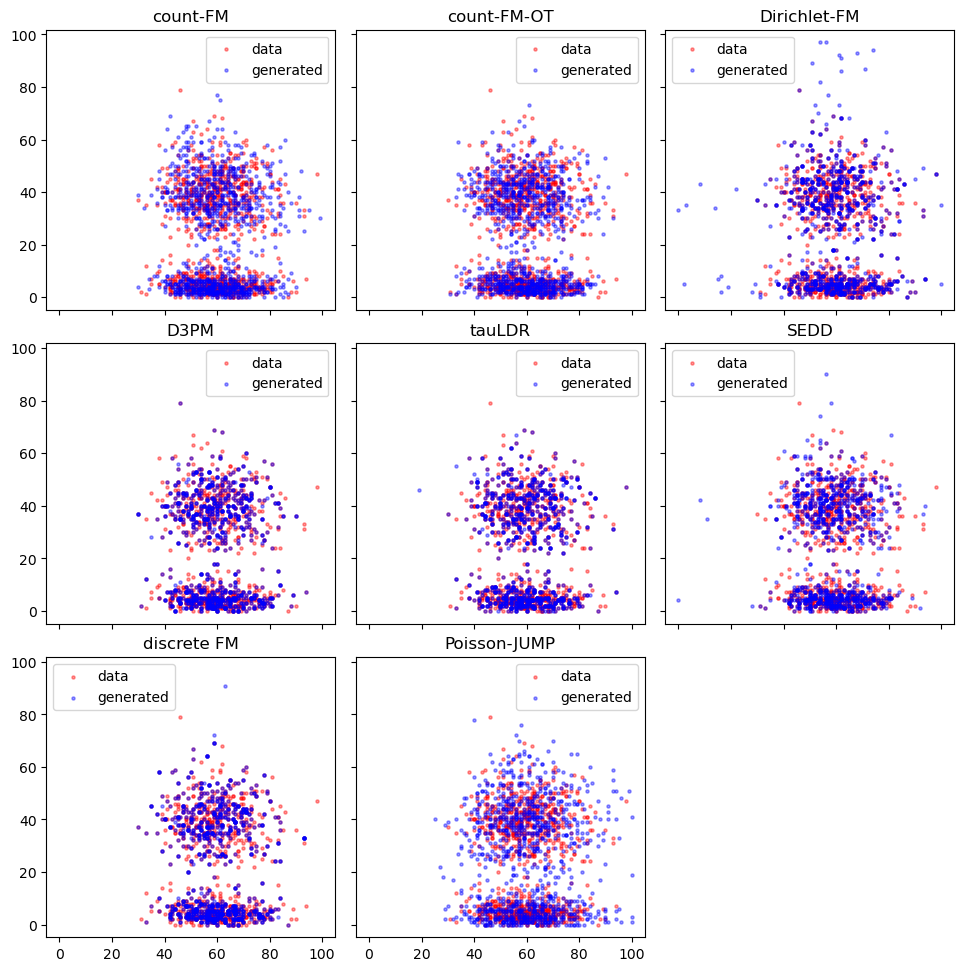

In [71]:
n_panels = 8

ncols = int(np.ceil(np.sqrt(n_panels)))
nrows = int(np.ceil(n_panels / ncols))

side = 3.2
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(side * ncols, side * nrows),
    sharex=True, sharey=True,
    constrained_layout=True,
)
axes = np.ravel(axes)

panel_data = [
    ("count-FM", x1_countFM_np),
    ("count-FM-OT", x1_countFM_OT_np),
    ("Dirichlet-FM", X1_DirFM_np),
    ("D3PM", X1_D3PM_np),
    ("tauLDR", x1_tauLDR_np),
    ("SEDD", X1_SEDD_np),
    ("discrete FM", X1_DisFM_np),
    ("Poisson-JUMP", X1_PJUMP_np),
]

for ax, (title, xg_np) in zip(axes, panel_data):
    ax.scatter(X1[:, 0], X1[:, 1], c="r", s=5, alpha=alpha_pt, label="data")
    ax.scatter(xg_np[:, 0], xg_np[:, 1], c="b", s=5, alpha=alpha_pt, label="generated")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.set_aspect("equal", adjustable="box")

for ax in axes[len(panel_data):]:
    ax.set_visible(False)

plt.show()

## 5.2 Generated trajectories
Let's just show snapshots (although count-FM is easy to show the whole trajectories)...

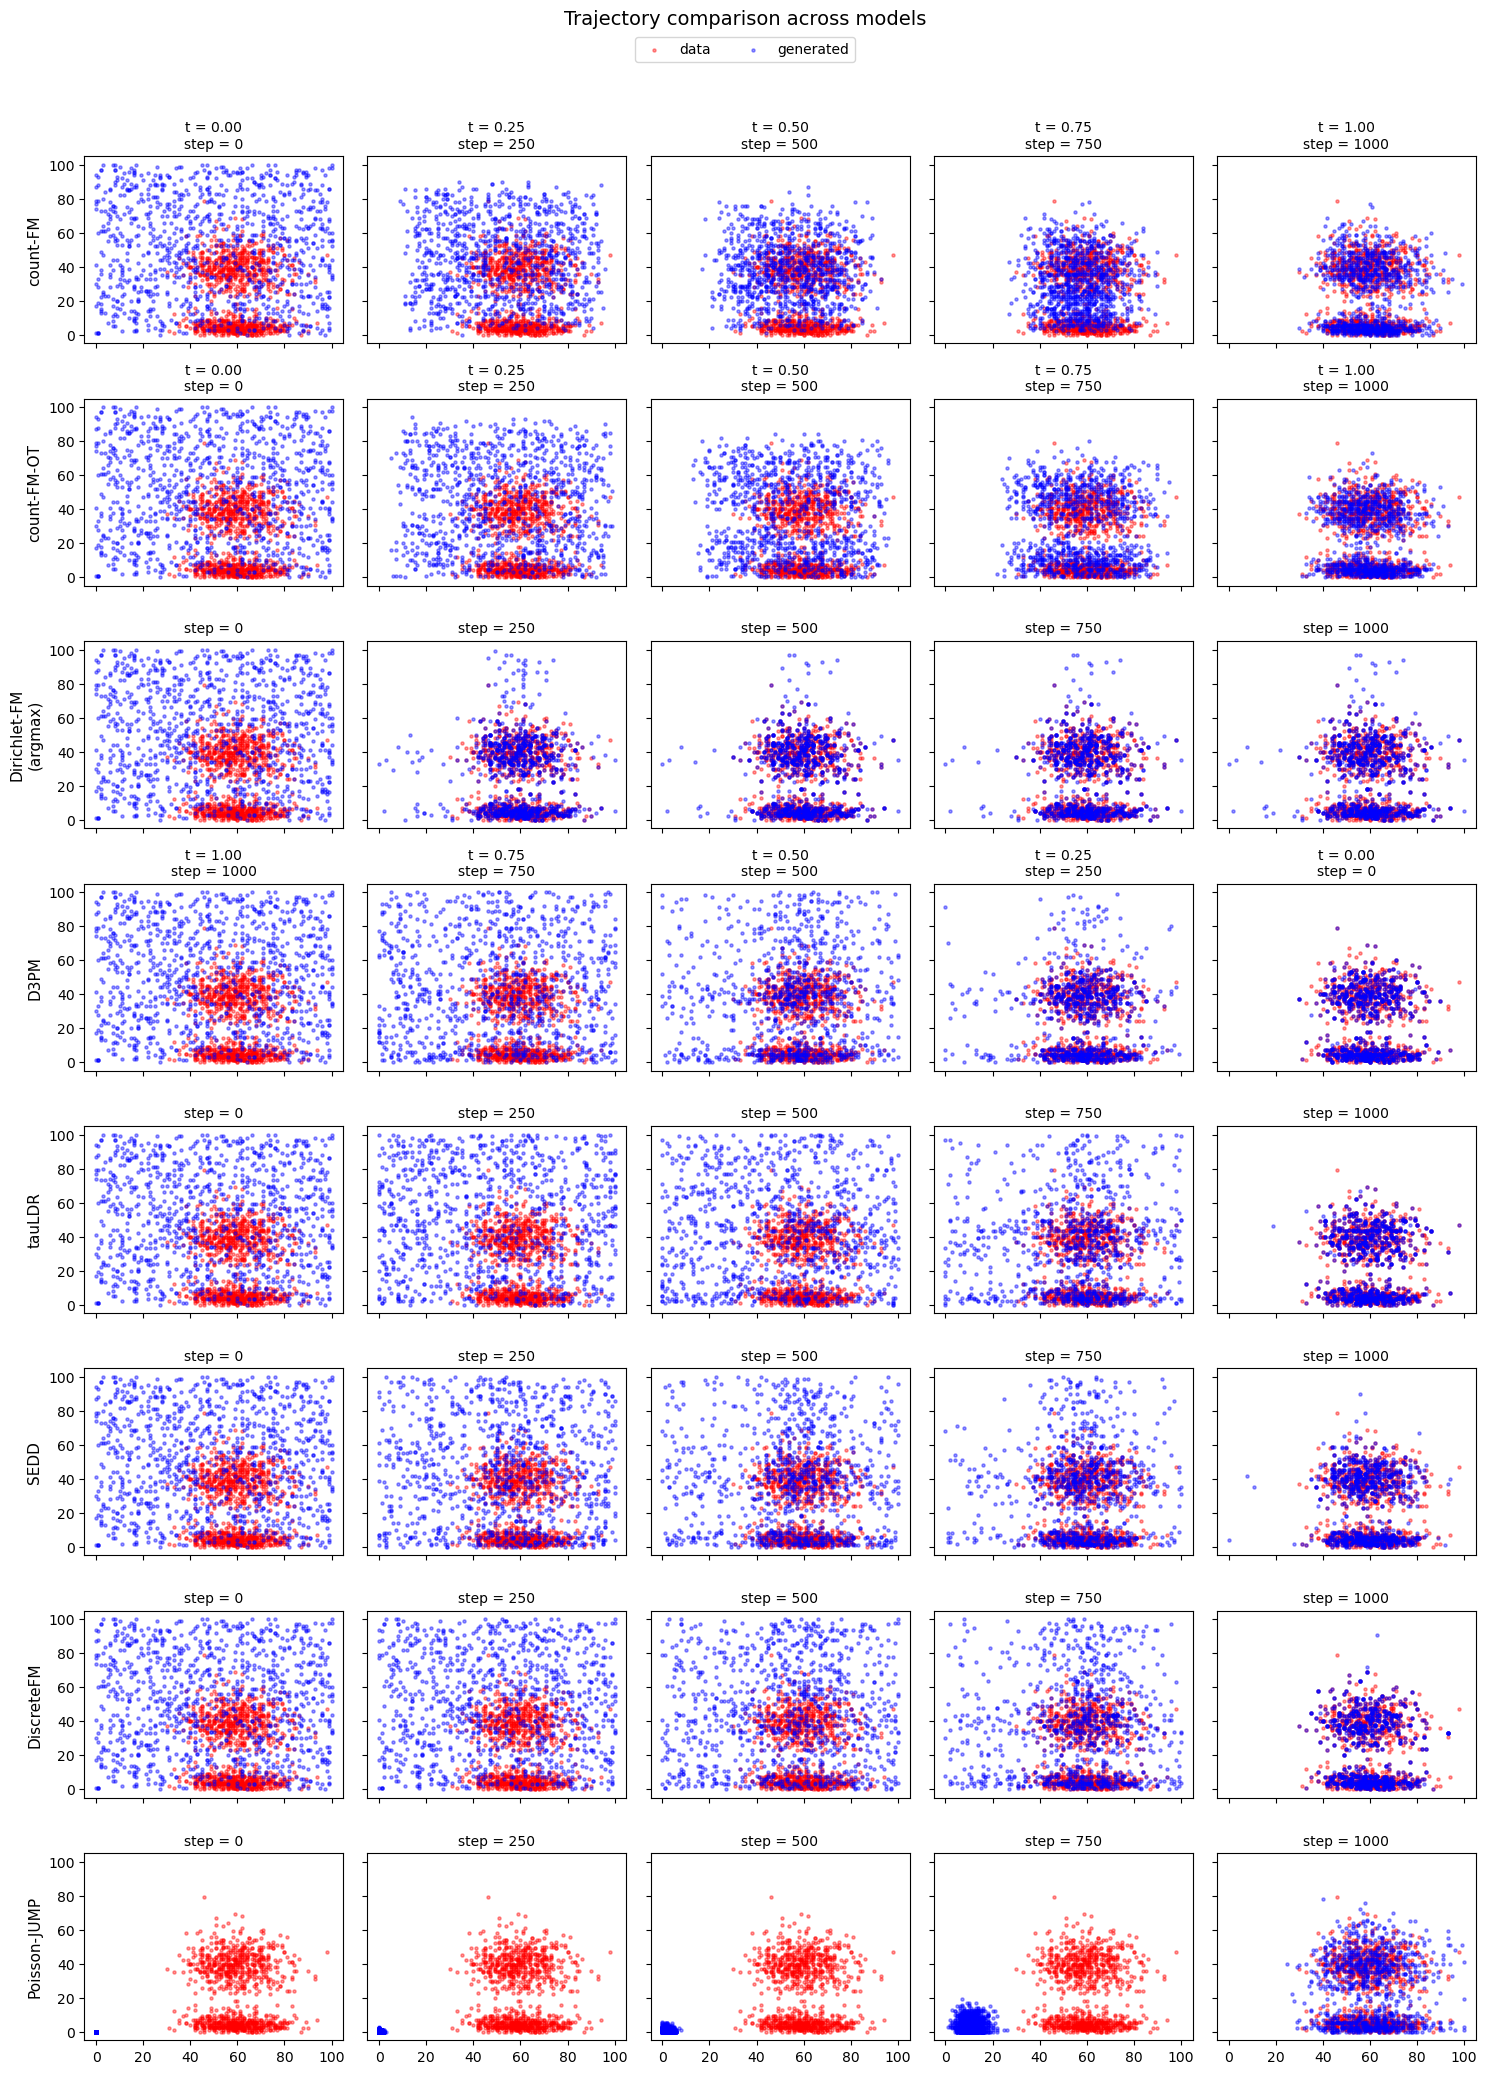

In [72]:
traj_DirFM_counts_np = traj_DirFM_np.argmax(axis=-1)

model_specs = [
    dict(
        traj_np=traj_countFM_np,
        row_label="count-FM",
        reverse=False,
        show_t=True,
        show_step=True,
        gen_label="generated",
    ),
    dict(
        traj_np=traj_countFM_OT_np,
        row_label="count-FM-OT",
        reverse=False,
        show_t=True,
        show_step=True,
        gen_label="generated",
    ),
    dict(
        traj_np=traj_DirFM_counts_np,
        row_label="Dirichlet-FM\n(argmax)",
        reverse=False,
        show_t=False,
        show_step=True,
        gen_label="generated (argmax)",
    ),
    dict(
        traj_np=traj_D3PM_np,
        row_label="D3PM",
        reverse=True,
        show_t=True,
        show_step=True,
        gen_label="generated",
    ),
    dict(
        traj_np=traj_tauLDR_np,
        row_label="tauLDR",
        reverse=False,
        show_t=False,
        show_step=True,
        gen_label="generated",
    ),
    dict(
        traj_np=traj_SEDD_np,
        row_label="SEDD",
        reverse=False,
        show_t=False,
        show_step=True,
        gen_label="generated",
    ),
    dict(
        traj_np=traj_DisFM_np,
        row_label="DiscreteFM",
        reverse=False,
        show_t=False,
        show_step=True,
        gen_label="generated",
    ),
    dict(
        traj_np=traj_PJUMP_np,
        row_label="Poisson-JUMP",
        reverse=False,
        show_t=False,
        show_step=True,
        gen_label="generated",
    ),
]

def _snapshot_ids(T, k, reverse=False):
    if reverse:
        return np.linspace(T, 0, k, dtype=int)
    return np.linspace(0, T, k, dtype=int)

k = 5
n_models = len(model_specs)

fig, axes = plt.subplots(
    n_models, k,
    figsize=(3 * k, 2.6 * n_models),
    sharex=True, sharey=True
)

if n_models == 1:
    axes = axes[None, :]

legend_handles = None
legend_labels = None

for i, spec in enumerate(model_specs):
    traj_np = spec["traj_np"]
    T = traj_np.shape[0] - 1
    snapshot_ids = _snapshot_ids(T, k, reverse=spec["reverse"])

    for j, t_idx in enumerate(snapshot_ids):
        ax = axes[i, j]

        h1 = ax.scatter(
            X1[:, 0], X1[:, 1],
            c="r", s=5, alpha=alpha_pt, label="data"
        )
        h2 = ax.scatter(
            traj_np[t_idx, :, 0], traj_np[t_idx, :, 1],
            c="b", s=5, alpha=alpha_pt, label=spec["gen_label"]
        )

        if legend_handles is None:
            legend_handles = [h1, h2]
            legend_labels = ["data", spec["gen_label"]]

        title_parts = []
        if spec["show_t"]:
            title_parts.append(f"t = {t_idx / T:.2f}")
        if spec["show_step"]:
            title_parts.append(f"step = {t_idx}")
        ax.set_title("\n".join(title_parts), fontsize=10)

        if j == 0:
            ax.set_ylabel(spec["row_label"], fontsize=11)

fig.suptitle("Trajectory comparison across models", fontsize=14, y=0.995)
fig.legend(
    legend_handles, legend_labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.985),
    frameon=True
)
plt.tight_layout(rect=[0, 0, 1, 0.965])

fig.savefig(
    os.path.join(FIG_DIR, "traj_all_models.pdf"),
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

In [69]:
def sample_target_toy(n, k, rate, mix_prob=0.5, seed=0):
    rng = np.random.default_rng(seed)
    z = (rng.random(n) < mix_prob).astype(int)
    lam = rng.gamma(shape=k[z], scale=1.0 / rate[z])
    x = rng.poisson(lam)
    return x.astype(np.int64)

def median_heuristic_gamma(x_np, max_points=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = x_np.shape[0]
    idx = rng.choice(n, size=min(n, max_points), replace=False)
    x = torch.tensor(x_np[idx], dtype=torch.float32)
    dist2 = torch.cdist(x, x, p=2).pow(2)
    vals = dist2[torch.triu(torch.ones_like(dist2, dtype=torch.bool), diagonal=1)]
    sigma2 = torch.median(vals).item()
    sigma2 = max(sigma2, 1e-8)
    return 1.0 / sigma2

def w2_empirical(x_np, y_np):
    x = np.asarray(x_np, dtype=np.float64)
    y = np.asarray(y_np, dtype=np.float64)
    a = np.ones(x.shape[0], dtype=np.float64) / x.shape[0]
    b = np.ones(y.shape[0], dtype=np.float64) / y.shape[0]
    M = ot.dist(x, y, metric="sqeuclidean")
    w2_sq = ot.emd2(a, b, M)
    return float(np.sqrt(max(w2_sq, 0.0)))

def mmd2_rbf_np(x_np, y_np, gamma):
    x = torch.tensor(x_np, dtype=torch.float32)
    y = torch.tensor(y_np, dtype=torch.float32)
    return float(mmd_rbf(x, y, gamma=gamma))

def summary_stats_np(x_np):
    x = torch.tensor(x_np, dtype=torch.float32)
    mean, var, zero = basic_stats(x)
    corr = corr_mat(x)
    return {
        "mean": mean,
        "var": var,
        "zero": zero,
        "corr": corr,
    }

def compare_stats(xg_np, xr_np):
    sg = summary_stats_np(xg_np)
    sr = summary_stats_np(xr_np)
    return {
        "mean_l1": float((sg["mean"] - sr["mean"]).abs().mean().item()),
        "var_l1": float((sg["var"] - sr["var"]).abs().mean().item()),
        "zero_l1": float((sg["zero"] - sr["zero"]).abs().mean().item()),
        "corr_frob": float(torch.norm(sg["corr"] - sr["corr"], p="fro").item()),
    }

# large fresh reference pool
N_REF = 50000
X_ref_big = sample_target_toy(
    N_REF,
    k=k_target,
    rate=rate_target,
    mix_prob=0.5,
    seed=2026,
)

# use one fixed gamma for all methods
gamma_rbf = median_heuristic_gamma(X_ref_big, max_points=2000, seed=2026)
print("gamma_rbf =", gamma_rbf)

gamma_rbf = 0.001351351239891981


/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/functional.py:1510: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return _VF.cdist(x1, x2, p, None)  # type: ignore[attr-defined]


In [70]:
gen_samples = {
    "count-FM": np.asarray(x1_countFM_np, dtype=np.int64),
    "count-FM-OT": np.asarray(x1_countFM_OT_np, dtype=np.int64),
    "Dirichlet-FM": np.asarray(X1_DirFM_np, dtype=np.int64),
    "D3PM": np.asarray(X1_D3PM_np, dtype=np.int64),
    "tauLDR": np.asarray(x1_tauLDR_np, dtype=np.int64),
    "SEDD": np.asarray(X1_SEDD_np, dtype=np.int64),
    "discrete-FM": np.asarray(X1_DisFM_np, dtype=np.int64),
    "Poisson-JUMP": np.asarray(X1_PJUMP_np, dtype=np.int64),
}

def eval_against_reference(xg_np, xref_big_np, gamma, n_rep=20, seed=123):
    rng = np.random.default_rng(seed)
    n = xg_np.shape[0]
    rows = []

    for r in range(n_rep):
        idx = rng.choice(xref_big_np.shape[0], size=n, replace=False)
        xr_np = xref_big_np[idx]

        row = {
            "W2": w2_empirical(xg_np, xr_np),
            "MMD2_RBF": mmd2_rbf_np(xg_np, xr_np, gamma=gamma),
        }
        row.update(compare_stats(xg_np, xr_np))
        rows.append(row)

    df = pd.DataFrame(rows)
    out = {}
    for c in df.columns:
        out[f"{c}_mean"] = df[c].mean()
        out[f"{c}_std"] = df[c].std(ddof=1)
    return out

results = []
for name, xg in gen_samples.items():
    stats = eval_against_reference(
        xg,
        X_ref_big,
        gamma_rbf,
        n_rep=20,
        seed=MODEL_SEEDS["eval"],
    )
    stats["model"] = name
    results.append(stats)

df_eval = pd.DataFrame(results)

df_eval["W2"] = df_eval.apply(lambda r: f'{r["W2_mean"]:.3f} ± {r["W2_std"]:.3f}', axis=1)
df_eval["MMD2_RBF"] = df_eval.apply(lambda r: f'{r["MMD2_RBF_mean"]:.4f} ± {r["MMD2_RBF_std"]:.4f}', axis=1)

cols_main = ["model", "W2", "MMD2_RBF"]
cols_full = [
    "model",
    "W2", "MMD2_RBF",
    "mean_l1_mean", "var_l1_mean", "zero_l1_mean", "corr_frob_mean",
    "W2_mean", "W2_std", "MMD2_RBF_mean", "MMD2_RBF_std",
]

df_eval = df_eval.sort_values(["W2_mean", "MMD2_RBF_mean"]).reset_index(drop=True)

display(df_eval[cols_main])
df_eval[cols_full]

/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/torch/utils/_device.py:103: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return func(*args, **kwargs)


,model,W2,MMD2_RBF
0,count-FM,2.879 ± 0.380,0.0001 ± 0.0007
1,count-FM-OT,2.971 ± 0.472,0.0002 ± 0.0006
2,D3PM,3.283 ± 0.510,0.0006 ± 0.0008
3,discrete-FM,3.360 ± 0.762,0.0009 ± 0.0015
4,tauLDR,3.733 ± 0.732,0.0008 ± 0.0010
5,SEDD,4.426 ± 0.811,0.0026 ± 0.0016
6,Poisson-JUMP,4.581 ± 0.595,0.0038 ± 0.0013
7,Dirichlet-FM,6.191 ± 0.677,0.0036 ± 0.0018


,model,W2,MMD2_RBF,mean_l1_mean,var_l1_mean,zero_l1_mean,corr_frob_mean,W2_mean,W2_std,MMD2_RBF_mean,MMD2_RBF_std
0,count-FM,2.879 ± 0.380,0.0001 ± 0.0007,0.464800,16.674620,0.00330,0.050501,2.878629,0.379742,0.000110,0.000655
1,count-FM-OT,2.971 ± 0.472,0.0002 ± 0.0006,0.526500,6.671142,0.00295,0.083061,2.971344,0.472300,0.000208,0.000577
2,D3PM,3.283 ± 0.510,0.0006 ± 0.0008,0.599900,9.263854,0.00330,0.062933,3.283068,0.509970,0.000591,0.000834
3,discrete-FM,3.360 ± 0.762,0.0009 ± 0.0015,0.624099,14.071349,0.00195,0.081556,3.360386,0.761719,0.000858,0.001537
4,tauLDR,3.733 ± 0.732,0.0008 ± 0.0010,0.726850,9.787371,0.00215,0.050838,3.732964,0.732391,0.000779,0.001011
5,SEDD,4.426 ± 0.811,0.0026 ± 0.0016,1.270900,13.948999,0.00215,0.067782,4.426118,0.811161,0.002606,0.001644
6,Poisson-JUMP,4.581 ± 0.595,0.0038 ± 0.0013,1.139400,42.419480,0.01020,0.047452,4.580532,0.595358,0.003826,0.001256
7,Dirichlet-FM,6.191 ± 0.677,0.0036 ± 0.0018,1.577700,43.476655,0.00215,0.070123,6.191105,0.676854,0.003561,0.001826


# save the checkpoints

In [52]:
import os, time, torch, json

save_dir = "./toy_model_ckpts"
os.makedirs(save_dir, exist_ok=True)

K = C_max + 1

run_meta = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "D": int(D),
    "d": int(d),
    "C_max": int(C_max),
    "K": int(K),
    "batch_size": int(batch_size),
    "num_epochs": int(num_epochs),
    "eps_t": float(eps_t),
    "eps_log": float(eps_log),
    "loss_mode": loss_mode,
    "n_step": int(n_step),
    "lr_common": float(lr),
    "lr_pjump": float(opt_PJUMP.param_groups[0]["lr"]),
}

with open(os.path.join(save_dir, "meta.json"), "w") as f:
    json.dump(run_meta, f, indent=2)

# # count-FM
# if nets_countFM is not None and opt_countFM is not None:
#     torch.save(
#         {
#             "model": nets_countFM,
#             "optimizer_state_dict": opt_countFM.state_dict(),
#             "meta": run_meta,
#         },
#         os.path.join(save_dir, "countFM.pt"),
#     )

if nets_countFM_OT is not None and opt_countFM_OT is not None:
    torch.save(
        {
            "model": nets_countFM_OT,
            "optimizer_state_dict": opt_countFM_OT.state_dict(),
            "meta": run_meta,
        },
        os.path.join(save_dir, "countFM_OT.pt"),
    )

# # Dirichlet-FM
# torch.save(
#     {
#         "model": classifier_DirFM,
#         "optimizer_state_dict": opt_DirFM.state_dict(),
#         "meta": run_meta,
#     },
#     os.path.join(save_dir, "DirichletFM.pt"),
# )

# # D3PM
# torch.save(
#     {
#         "model": classifier_D3PM,
#         "optimizer_state_dict": opt_D3PM.state_dict(),
#         "meta": run_meta,
#     },
#     os.path.join(save_dir, "D3PM.pt"),
# )

# # tauLDR
# torch.save(
#     {
#         "model": classifier_tauLDR,
#         "optimizer_state_dict": opt_tauLDR.state_dict(),
#         "meta": run_meta,
#     },
#     os.path.join(save_dir, "tauLDR.pt"),
# )

# # SEDD
# torch.save(
#     {
#         "model": classifier_SEDD,
#         "optimizer_state_dict": opt_SEDD.state_dict(),
#         "meta": run_meta,
#     },
#     os.path.join(save_dir, "SEDD.pt"),
# )

# # discrete-FM
# torch.save(
#     {
#         "model": classifier_DisFM,
#         "optimizer_state_dict": opt_DisFM.state_dict(),
#         "meta": run_meta,
#     },
#     os.path.join(save_dir, "discreteFM.pt"),
# )

# # Poisson-JUMP
# torch.save(
#     {
#         "model": decoder_PJUMP,
#         "optimizer_state_dict": opt_PJUMP.state_dict(),
#         "meta": run_meta,
#     },
#     os.path.join(save_dir, "PoissonJUMP.pt"),
# )

# print("Saved all 8 models to:", os.path.abspath(save_dir))
# print(sorted(os.listdir(save_dir)))